# Method 1 — User-User Collaborative Filtering
### RQ1: At what sparsity level does SVD outperform CF? — Method 1 only

**Sparsity levels (from diagram):** 5 levels → 50%, 65%, 80%, 90%, 99% missing

---

## Install dependencies


In [ ]:
import sys
!conda install -c conda-forge numpy pandas scipy scikit-learn matplotlib -y --quiet
print('Done')

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split

os.makedirs('results/figures', exist_ok=True)
print('All imports OK')

All imports OK


## Sparsity levels
Exactly as defined in diagram Phase 1: **5 levels, 50–99% missing**

In [2]:
# Diagram Phase 1: 'Randomly mask ratings → 5 levels (50–99% missing)'
SPARSITY_LEVELS = [0.50, 0.65, 0.80, 0.90, 0.99]
SPARSITY_LABELS = ['50%', '65%', '80%', '90%', '99%']
K = 20   # neighbourhood size
print('Sparsity levels:', SPARSITY_LABELS)
print(f'Neighbourhood size k = {K}')

Sparsity levels: ['50%', '65%', '80%', '90%', '99%']
Neighbourhood size k = 20


## Data pipeline helpers
Covers diagram Phase 0 (load), Phase 1 (sparsity simulation), Phase 2 (80/20 split)

In [3]:
# Phase 0: Load MovieLens 
def load_movielens(path, sep='::'):
    df = pd.read_csv(
        path, sep=sep, engine='python',
        names=['userId', 'movieId', 'rating', 'timestamp']
    )
    print(f'Loaded {len(df):,} ratings | '
          f'{df.userId.nunique():,} users | '
          f'{df.movieId.nunique():,} movies')
    return df

# Phase 1: Simulate sparsity 
def simulate_sparsity(df, missing_fraction, seed=42):
    
    np.random.seed(seed)
    n_keep = int(len(df) * (1.0 - missing_fraction))
    idx    = np.random.choice(len(df), size=n_keep, replace=False)
    sub    = df.iloc[idx].reset_index(drop=True)
    print(f'  {missing_fraction:.0%} missing → {len(sub):,} ratings kept')
    return sub

# Phase 2: Train/test split 80/20 
def split_80_20(df, seed=42):
    train, test = train_test_split(df, test_size=0.20, random_state=seed)
    return train.reset_index(drop=True), test.reset_index(drop=True)

# Build sparse matrix 
def build_matrix(df):
    user_map = {u: i for i, u in enumerate(df.userId.unique())}
    item_map = {m: i for i, m in enumerate(df.movieId.unique())}
    rows = df.userId.map(user_map).values
    cols = df.movieId.map(item_map).values
    mat  = csr_matrix(
        (df.rating.values.astype(float), (rows, cols)),
        shape=(len(user_map), len(item_map))
    )
    return mat, user_map, item_map

print('Data pipeline functions ready')

Data pipeline functions ready


## Pearson similarity

**Exact SVG label:** *User-user CF · Pearson similarity*

**Why Pearson (not cosine)?**
Cosine similarity treats unrated items as a rating of 0, which pollutes the score. Pearson mean-centres each user's ratings over **co-rated items only**, so a user who always gives 5★ and one who averages 3★ can still be highly similar if their tastes move together.

**Formula:**

$$\text{sim}(u,v) = \frac{\sum_i (r_{ui} - \bar{r}_u)(r_{vi} - \bar{r}_v)}{\sqrt{\sum_i(r_{ui}-\bar{r}_u)^2} \cdot \sqrt{\sum_i(r_{vi}-\bar{r}_v)^2}}$$

Summation is over items rated by **both** u and v.

In [4]:
def compute_pearson_similarity(matrix):
    """
    Pearson similarity between every user pair.

    Steps:
      1. Compute each user's mean over their rated items only
      2. Mean-centre: subtract mean from rated cells, leave 0s unchanged
      3. Pearson(u,v) = dot(centred_u, centred_v) / (norm_u * norm_v)
         This naturally considers only co-rated items because
         unrated cells are 0 in both vectors.

    Returns:
      sim        : (n_users, n_users) float32 array
      user_means : (n_users,) mean rating per user
    """
    dense = matrix.toarray().astype(np.float32)  # (n_users, n_items)
    n     = dense.shape[0]

    # Step 1 — per-user mean over rated items only
    user_means = np.zeros(n, dtype=np.float32)
    for u in range(n):
        rated = dense[u] > 0
        if rated.any():
            user_means[u] = dense[u, rated].mean()

    # Step 2 — mean-centre (only rated cells)
    centred = dense.copy()
    for u in range(n):
        rated = centred[u] > 0
        centred[u, rated] -= user_means[u]

    # Step 3 — Pearson = dot / (norm_u * norm_v)
    norms = np.linalg.norm(centred, axis=1)  # (n,)
    sim   = np.zeros((n, n), dtype=np.float32)

    for u in range(n):
        for v in range(u + 1, n):
            denom = norms[u] * norms[v]
            if denom == 0:
                continue
            s = float(np.dot(centred[u], centred[v]) / denom)
            sim[u, v] = s
            sim[v, u] = s   # symmetric

    np.fill_diagonal(sim, 0)  # exclude self-similarity
    return sim, user_means

print('Compute_pearson_similarity() defined')

Compute_pearson_similarity() defined


## Find k neighbours

**Exact SVG label:** *Find k neighbours · Per user, by rating sim*

For a target user `u` and item `i`:
1. Filter to only users who have actually rated item `i`
2. Among those, rank by `sim(u, v)` descending
3. Keep the top-k with positive similarity

This is 'per user' because we repeat this lookup for every prediction of user u.

In [5]:
def find_k_neighbours(u, item_idx, sim_matrix, dense_matrix, k):
    """
    Find k neighbours per user, by rating sim.

    Args:
        u           : target user index
        item_idx    : target item index
        sim_matrix  : (n_users, n_users) Pearson similarity
        dense_matrix: (n_users, n_items) dense rating matrix
        k           : neighbourhood size

    Returns:
        neighbours : indices of top-k similar users who rated item_idx
        weights    : their similarity scores to user u
    """
    # Who has rated item_idx?
    raters_mask = dense_matrix[:, item_idx] > 0      # boolean (n_users,)

    # Similarity of u to every rater; zero out non-raters
    masked_sims = sim_matrix[u] * raters_mask

    if masked_sims.max() <= 0:
        return np.array([], dtype=int), np.array([], dtype=np.float32)

    # Top-k by similarity
    top_k_idx = np.argsort(masked_sims)[-k:]
    weights   = masked_sims[top_k_idx]

    # Keep only positive-similarity neighbours
    positive  = weights > 0
    return top_k_idx[positive], weights[positive]

print('Find_k_neighbours() defined')

Find_k_neighbours() defined


## Predict rating

**Exact SVG label:** *Predict rating · Weighted avg of neighbours*

**Formula (bias-corrected weighted average):**

$$\hat{r}(u,i) = \bar{r}_u + \frac{\sum_{v \in N(u)} \text{sim}(u,v) \cdot (r(v,i) - \bar{r}_v)}{\sum_{v \in N(u)} |\text{sim}(u,v)|}$$

The term $(r(v,i) - \bar{r}_v)$ removes each neighbour's own rating bias before averaging, so a neighbour who habitually rates high does not inflate the prediction.

In [6]:
def predict_rating(u, item_idx, neighbours, weights,
                   dense_matrix, user_means, global_mean):
    """
    Predict rating: weighted avg of neighbours.

    Formula:
        r_hat(u,i) = mean_u + dot(weights, r(v,i) - mean_v) / sum(weights)

    Falls back to global_mean when no neighbours found (cold start).
    Result is clipped to [1, 5] — the valid MovieLens rating range.
    """
    if len(neighbours) == 0:
        return global_mean   # cold-start fallback

    w_sum = weights.sum()
    if w_sum == 0:
        return global_mean

    # Bias-corrected neighbour ratings: r(v,i) - mean_v
    adj_ratings = np.array([
        dense_matrix[v, item_idx] - user_means[v]
        for v in neighbours
    ])

    prediction = user_means[u] + np.dot(weights, adj_ratings) / w_sum
    return float(np.clip(prediction, 1.0, 5.0))

print('Predict_rating() defined')

Predict_rating() defined


## Full UserUserCF class
Combines all three diagram boxes into one `fit()` / `predict_batch()` interface.

In [7]:
class UserUserCF:
    """
    Method 1- User-User Collaborative Filtering
    Implements all 3 steps from project_architecture_plan.svg (purple track).

    Box 1: Pearson similarity between every user pair
    Box 2: Find k neighbours per user, by rating similarity
    Box 3: Predict rating as bias-corrected weighted average of neighbours
    """

    def __init__(self, k=20):
        self.k = k

    def fit(self, matrix):
        """Build Pearson similarity matrix."""
        self.matrix      = matrix
        self.dense       = matrix.toarray().astype(np.float32)
        self.global_mean = float(matrix.data.mean())

        print('  Computing Pearson similarity matrix ...')
        self.sim, self.user_means = compute_pearson_similarity(matrix)
        print(f'  Similarity matrix shape: {self.sim.shape}')
        return self

    def _predict_one(self, u, item_idx):
        """Run  2 then  3 for a single (user, item) pair."""
        # Box 2 — find neighbours
        neighbours, weights = find_k_neighbours(
            u, item_idx, self.sim, self.dense, self.k
        )
        # Box 3 — predict
        return predict_rating(
            u, item_idx, neighbours, weights,
            self.dense, self.user_means, self.global_mean
        )

    def predict_batch(self, pairs):
        """Predict ratings for a list of (user_idx, item_idx) pairs."""
        return [self._predict_one(u, i) for u, i in pairs]

print('UserUserCF class defined')

UserUserCF class defined


## Evaluation function
Phase 3: *RMSE on test set · per sparsity level*

In [8]:
def evaluate(model, test_df, user_map, item_map):
    """
    Diagram Phase 3: RMSE on test set per sparsity level.
    Returns (rmse, inference_time_seconds).
    Skips test pairs where user or item was not seen in training.
    """
    pairs, truth = [], []
    for _, row in test_df.iterrows():
        u = user_map.get(row.userId)
        i = item_map.get(row.movieId)
        if u is not None and i is not None:
            pairs.append((u, i))
            truth.append(float(row.rating))

    if len(pairs) == 0:
        return float('nan'), 0.0

    t0      = time.perf_counter()
    preds   = model.predict_batch(pairs)
    elapsed = time.perf_counter() - t0

    errors  = np.array(truth) - np.array(preds)
    rmse    = float(np.sqrt(np.mean(errors ** 2)))
    return rmse, elapsed

print('evaluate() function defined')

evaluate() function defined


## Load MovieLens 1M
Place `ratings.dat` in `data/ml-1m/` next to this notebook.

In [11]:
ratings = load_movielens('C:/Users/HP/Music/Scaleable_Project/ml-1m/ratings.dat')

density = len(ratings) / (ratings.userId.nunique() * ratings.movieId.nunique())
print(f'\nNatural density  : {density:.5f}')
print(f'Naturally sparse : {(1-density)*100:.1f}% missing at full size')
ratings.head()

Loaded 1,000,209 ratings | 6,040 users | 3,706 movies

Natural density  : 0.04468
Naturally sparse : 95.5% missing at full size


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


## Smoke test
Run Method 1 on a single sparsity level (80% missing) to verify all three boxes work correctly before the full experiment.

In [12]:
print('=== Smoke test: 80% missing ===')
sub         = simulate_sparsity(ratings, missing_fraction=0.80)
train, test = split_80_20(sub)
mat, um, im = build_matrix(train)

print(f'Matrix: {mat.shape[0]} users × {mat.shape[1]} items')
print(f'Density: {mat.nnz / (mat.shape[0]*mat.shape[1]):.5f}')

model       = UserUserCF(k=K).fit(mat)
rmse, t_inf = evaluate(model, test, um, im)

print(f'\nSmoke test result:')
print(f'  RMSE            : {rmse:.4f}')
print(f'  Inference time  : {t_inf:.2f}s')
print('\nAll 3 diagram boxes working correctly.')

=== Smoke test: 80% missing ===
  80% missing → 200,041 ratings kept
Matrix: 6030 users × 3409 items
Density: 0.00779
  Computing Pearson similarity matrix ...
  Similarity matrix shape: (6030, 6030)

Smoke test result:
  RMSE            : 0.9703
  Inference time  : 13.96s

All 3 diagram boxes working correctly.


## Full experiment
Method 1 across all 5 sparsity levels from the diagram.

> **Note:** The Pearson similarity loop is pure Python. On 1M data at low sparsity (50% missing ≈ 500K ratings), each level may take 5–15 minutes. Run the smoke test first. If too slow, uncomment the `sample` line below to test on 10% of data.

In [13]:
# Uncomment to test on 10% of data first (much faster)
# ratings = ratings.sample(frac=0.10, random_state=42).reset_index(drop=True)

results = []

for level, label in zip(SPARSITY_LEVELS, SPARSITY_LABELS):
    print(f"\n{'─'*50}")
    print(f'Sparsity level : {label} missing')
    print(f"{'─'*50}")

    # Phase 1 — simulate sparsity
    sub         = simulate_sparsity(ratings, missing_fraction=level)

    # Phase 2 — 80/20 split
    train, test = split_80_20(sub)

    # Build matrix
    mat, um, im = build_matrix(train)
    density     = mat.nnz / (mat.shape[0] * mat.shape[1])
    print(f'  Matrix: {mat.shape[0]} users × {mat.shape[1]} items | density={density:.5f}')

    # Box 1 — Pearson similarity (inside .fit)
    t0    = time.perf_counter()
    model = UserUserCF(k=K).fit(mat)
    t_fit = time.perf_counter() - t0

    # Box 2 + 3 — find neighbours + predict (inside evaluate)
    rmse, t_inf = evaluate(model, test, um, im)
    t_total     = t_fit + t_inf

    print(f'  RMSE       : {rmse:.4f}')
    print(f'  Fit time   : {t_fit:.1f}s')
    print(f'  Total time : {t_total:.1f}s')

    results.append(dict(
        label    = label,
        level    = level,
        density  = round(density, 6),
        n_train  = len(train),
        n_test   = len(test),
        rmse     = round(rmse, 4),
        fit_time = round(t_fit, 2),
        total_time = round(t_total, 2),
    ))

df = pd.DataFrame(results)
os.makedirs('results', exist_ok=True)
df.to_csv('results/method1_uu_cf.csv', index=False)
print('\nSaved → results/method1_uu_cf.csv')
df


──────────────────────────────────────────────────
Sparsity level : 50% missing
──────────────────────────────────────────────────
  50% missing → 500,104 ratings kept
  Matrix: 6040 users × 3585 items | density=0.01848
  Computing Pearson similarity matrix ...
  Similarity matrix shape: (6040, 6040)
  RMSE       : 0.9247
  Fit time   : 186.1s
  Total time : 214.5s

──────────────────────────────────────────────────
Sparsity level : 65% missing
──────────────────────────────────────────────────
  65% missing → 350,073 ratings kept
  Matrix: 6039 users × 3538 items | density=0.01311
  Computing Pearson similarity matrix ...
  Similarity matrix shape: (6039, 6039)
  RMSE       : 0.9396
  Fit time   : 148.2s
  Total time : 168.3s

──────────────────────────────────────────────────
Sparsity level : 80% missing
──────────────────────────────────────────────────
  80% missing → 200,041 ratings kept
  Matrix: 6030 users × 3409 items | density=0.00779
  Computing Pearson similarity matrix ...

,label,level,density,n_train,n_test,rmse,fit_time,total_time
0,50%,0.50,0.018477,400083,100021,0.9247,186.11,214.49
1,65%,0.65,0.013108,280058,70015,0.9396,148.22,168.28
2,80%,0.80,0.007785,160032,40009,0.9703,142.84,151.76
3,90%,0.90,0.004203,80016,20004,1.0374,120.94,125.60
4,99%,0.99,0.001111,8001,2001,1.0762,25.65,25.74


## Plot: RMSE vs sparsity
This curve shows how User-User CF (Method 1) degrades as data becomes sparser. It will be compared against Method 2 and Method 3 in the final combined plot.

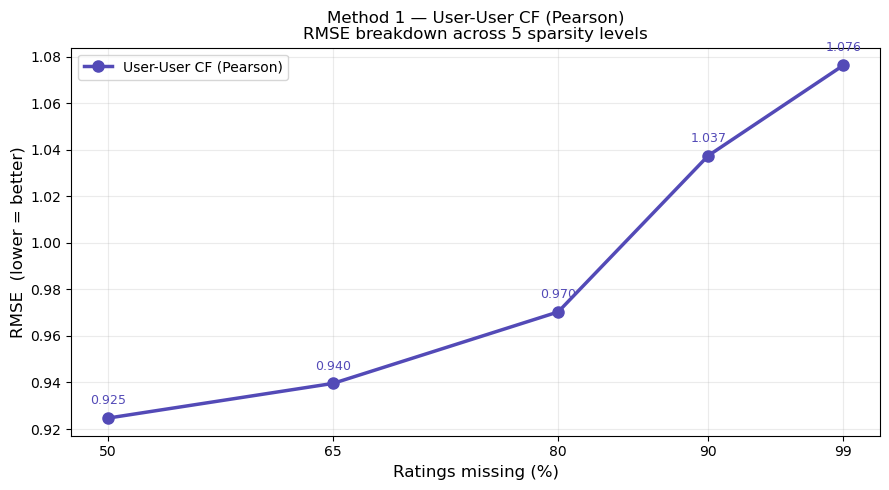

Saved: results/figures/method1_rmse.png


In [14]:
x = [int(l.replace('%','')) for l in df.label]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, df.rmse, 'o-', color='#534AB7',
        label='User-User CF (Pearson)', linewidth=2.5, markersize=8)

# Annotate each point with its RMSE value
for xi, yi in zip(x, df.rmse):
    ax.annotate(f'{yi:.3f}', (xi, yi),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#534AB7')

ax.set_xlabel('Ratings missing (%)', fontsize=12)
ax.set_ylabel('RMSE  (lower = better)', fontsize=12)
ax.set_title('Method 1 — User-User CF (Pearson)\nRMSE breakdown across 5 sparsity levels',
             fontsize=12)
ax.set_xticks(x)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('results/figures/method1_rmse.png', dpi=150)
plt.show()
print('Saved: results/figures/method1_rmse.png')

## Runtime vs sparsity

Shows how Pearson similarity computation time scales with the number of retained ratings. At low sparsity (50% missing) there are more users with more co-rated items, making the similarity loop slower.

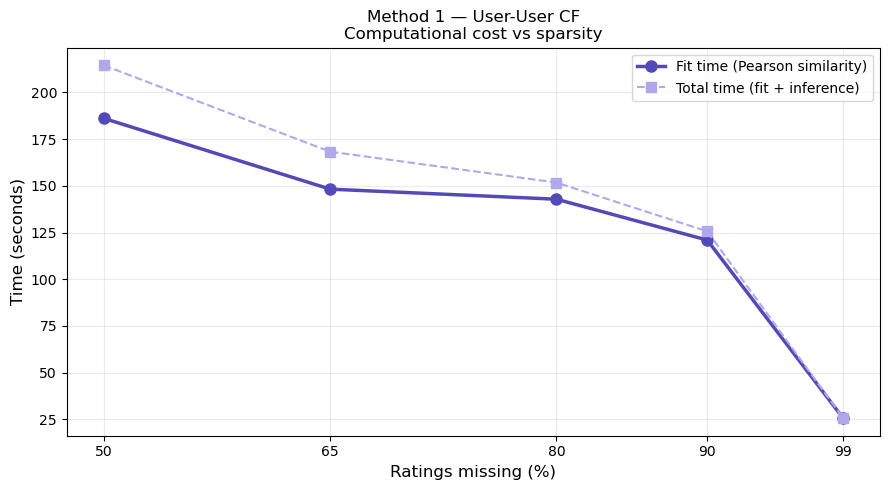

Saved: results/figures/method1_runtime.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, df.fit_time, 'o-', color='#534AB7',
        label='Fit time (Pearson similarity)', linewidth=2.5, markersize=8)
ax.plot(x, df.total_time, 's--', color='#AFA9EC',
        label='Total time (fit + inference)', linewidth=1.5, markersize=7)

ax.set_xlabel('Ratings missing (%)', fontsize=12)
ax.set_ylabel('Time (seconds)', fontsize=12)
ax.set_title('Method 1 — User-User CF\nComputational cost vs sparsity', fontsize=12)
ax.set_xticks(x)
ax.legend(fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('results/figures/method1_runtime.png', dpi=150)
plt.show()
print('Saved: results/figures/method1_runtime.png')

## Combined plot: RMSE and runtime on dual axis
Shows the accuracy-speed trade-off in one chart — useful for the report discussion section.

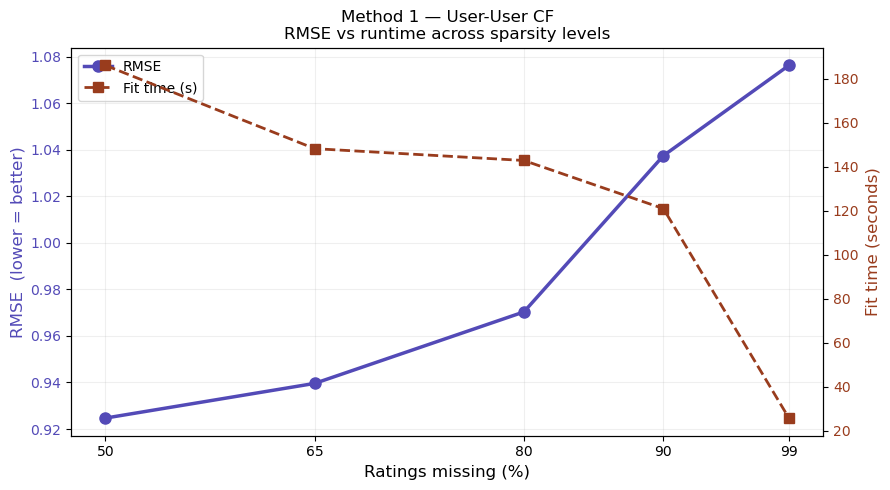

Saved: results/figures/method1_combined.png


In [16]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color_rmse    = '#534AB7'
color_runtime = '#993C1D'

ax1.plot(x, df.rmse, 'o-', color=color_rmse,
         label='RMSE', linewidth=2.5, markersize=8)
ax1.set_xlabel('Ratings missing (%)', fontsize=12)
ax1.set_ylabel('RMSE  (lower = better)', color=color_rmse, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_rmse)
ax1.set_xticks(x)

ax2 = ax1.twinx()
ax2.plot(x, df.fit_time, 's--', color=color_runtime,
         label='Fit time (s)', linewidth=2, markersize=7)
ax2.set_ylabel('Fit time (seconds)', color=color_runtime, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_runtime)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=10, loc='upper left')

ax1.set_title('Method 1 — User-User CF\nRMSE vs runtime across sparsity levels',
              fontsize=12)
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('results/figures/method1_combined.png', dpi=150)
plt.show()
print('Saved: results/figures/method1_combined.png')

## Method 1 findings summary
Prints a structured breakdown of how User-User CF performs at each sparsity level. Use this output directly in your report's results section.

In [17]:
print('=' * 55)
print('METHOD 1 — USER-USER CF (Pearson) — RESULTS SUMMARY')
print('=' * 55)
print(f'  Neighbourhood size k = {K}')
print(f'  Similarity           = Pearson (bias-corrected)')
print(f'  Dataset              = MovieLens 1M')
print(f'  Split                = 80% train / 20% test')
print()
print(f'{"Sparsity":>10}  {"Ratings kept":>14}  {"RMSE":>8}  {"Fit time":>10}')
print('-' * 50)
for _, row in df.iterrows():
    print(f'{row.label:>10}  {row.n_train:>14,}  {row.rmse:>8.4f}  {row.fit_time:>8.1f}s')

print()
best  = df.loc[df.rmse.idxmin()]
worst = df.loc[df.rmse.idxmax()]
print(f'Best RMSE  : {best.rmse:.4f} at {best.label} missing')
print(f'Worst RMSE : {worst.rmse:.4f} at {worst.label} missing')
print(f'Degradation: +{worst.rmse - best.rmse:.4f} RMSE from {best.label} to {worst.label}')
print()
print('Output files:')
print('  results/method1_uu_cf.csv')
print('  results/figures/method1_rmse.png')
print('  results/figures/method1_runtime.png')
print('  results/figures/method1_combined.png')

METHOD 1 — USER-USER CF (Pearson) — RESULTS SUMMARY
  Neighbourhood size k = 20
  Similarity           = Pearson (bias-corrected)
  Dataset              = MovieLens 1M
  Split                = 80% train / 20% test

  Sparsity    Ratings kept      RMSE    Fit time
--------------------------------------------------
       50%         400,083    0.9247     186.1s
       65%         280,058    0.9396     148.2s
       80%         160,032    0.9703     142.8s
       90%          80,016    1.0374     120.9s
       99%           8,001    1.0762      25.6s

Best RMSE  : 0.9247 at 50% missing
Worst RMSE : 1.0762 at 99% missing
Degradation: +0.1515 RMSE from 50% to 99%

Output files:
  results/method1_uu_cf.csv
  results/figures/method1_rmse.png
  results/figures/method1_runtime.png
  results/figures/method1_combined.png
